# 实验 02: 铣床设备故障预测全流程

**课程**: 工业大数据分析 / 机器学习进阶  
**核心知识点**: 
1.  **大数据处理**: 50万条物理仿真数据。
2.  **不平衡分类**: 对比“普通模型”与“加权模型”的效果。
3.  **深度评估**: ROC 曲线、AUC 值与抗噪性验证。
4.  **业务决策**: 通过 **阈值移动 (Threshold Moving)** 权衡漏报与误报。

## 1. 实验背景
在真实的工业预测性维护（PdM）场景中，我们面临三大挑战：
* **数据量大且脏**：传感器数据源源不断，且包含无用的噪声。
* **故障极少**：99% 的时间机器都是正常的（类别不平衡）。
* **漏报代价高**：没预测出故障导致的停机损失，远大于误报检查的成本。

本实验将模拟这一全过程，从数据生成到模型落地的核心技能。

In [ ]:
# 1. 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, auc)

# 设置绘图风格
plt.style.use('seaborn-v0_8')
print(" 核心库导入完成！")

✅ 核心库导入完成！


## 2. 数据集构建：百万级物理仿真

为了模拟真实的“脏”数据，我们编写代码生成 **50万条** 仿真数据。
我们刻意加入了 **5 个纯噪声特征 (`Noise_Sensor`)**，它们与故障无关。优秀的模型应该能自动忽略它们。

In [ ]:
def generate_big_industrial_data(n_samples=500000, random_state=42):
    np.random.seed(random_state)
    print(f" 正在生成 {n_samples} 条仿真数据...")
    start_time = time.time()
    
    # 1. 基础特征 (模拟传感器)
    data = {
        'Air temperature [K]': np.random.normal(300, 2, n_samples),
        'Process temperature [K]': np.random.normal(310, 2, n_samples),
        'Rotational speed [rpm]': np.random.randint(1200, 2800, n_samples),
        'Torque [Nm]': np.random.normal(40, 10, n_samples),
        'Tool wear [min]': np.random.randint(0, 250, n_samples)
    }
    df = pd.DataFrame(data)
    
    # 2. 注入干扰特征 (纯随机噪声)
    # 进阶点：测试模型能否识别出这些是垃圾特征
    for i in range(1, 6):
        df[f'Noise_Sensor_{i}'] = np.random.rand(n_samples)
    
    # 3. 故障逻辑 (基于物理规则)
    # 功率故障
    power = df['Rotational speed [rpm]'] * df['Torque [Nm]']
    fail_power = (power > 160000).astype(int)
    # 磨损故障
    fail_wear = ((df['Tool wear [min]'] > 220) & (df['Torque [Nm]'] > 55)).astype(int)
    # 散热故障
    temp_diff = df['Process temperature [K]'] - df['Air temperature [K]']
    fail_heat = ((temp_diff < 8.6) & (df['Rotational speed [rpm]'] < 1380)).astype(int)
    # 随机故障
    fail_random = np.random.choice([0, 1], size=n_samples, p=[0.998, 0.002])
    
    df['Machine failure'] = np.clip(fail_power + fail_wear + fail_heat + fail_random, 0, 1)
    
    print(f" 数据生成耗时: {time.time() - start_time:.2f} 秒 | 内存占用: {df.memory_usage().sum()/1024**2:.1f} MB")
    return df

# 生成数据
df = generate_big_industrial_data(500000)

⚡ 正在生成 500000 条仿真数据...
✅ 数据生成耗时: 0.10 秒 | 内存占用: 38.1 MB


## 3. 数据探索 (EDA)

首先检查**正负样本比例**。如果比例失衡严重，准确率（Accuracy）将失去参考价值。

In [ ]:
count = df['Machine failure'].value_counts()
ratio = count[1] / len(df) * 100

print(f"正常样本 (0): {count[0]}")
print(f"故障样本 (1): {count[1]}")
print(f"故障率: {ratio:.2f}%")

if ratio < 5:
    print(" 警告：数据极度不平衡！普通模型可能会失效。")

# 划分数据集 (使用 stratify 保持分布一致)
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

正常样本 (0): 475967
故障样本 (1): 24033
故障率: 4.81%
⚠️ 警告：数据极度不平衡！普通模型可能会失效。


## 4. 第一阶段：对比实验 (Baseline vs Balanced)

为了直观展示不平衡数据的影响，我们训练两个模型进行 PK：
1.  **基准模型 (Standard RF)**: 默认参数，不处理不平衡。
2.  **优化模型 (Balanced RF)**: 加入 `class_weight='balanced'`，增加故障样本的权重。

In [ ]:
print(" 正在并行训练两个模型... (这可能需要 1 分钟)")
t0 = time.time()

# 1. 基准模型
rf_base = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_base.fit(X_train, y_train)

# 2. 优化模型 (关键参数: class_weight='balanced')
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
rf_balanced.fit(X_train, y_train)

print(f" 训练完成！总耗时: {time.time() - t0:.2f} 秒")

🚀 正在并行训练两个模型... (这可能需要 1 分钟)
✅ 训练完成！总耗时: 91.40 秒


## 5. 效果评估：为什么准确率会骗人？

对比混淆矩阵，你会发现基准模型虽然准确率高，但**漏报（False Negative）**非常严重。

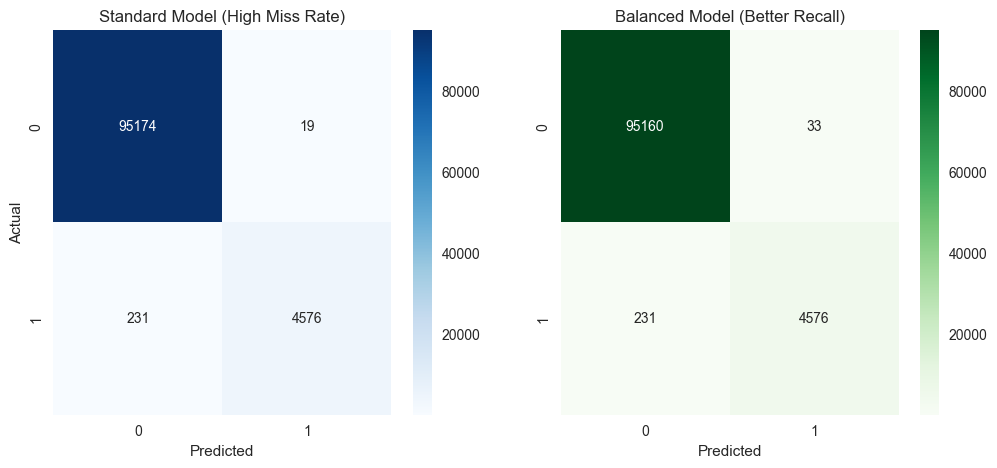

🔍 结论：加权模型 (右图) 抓住了更多的故障样本！虽然误报稍微增加，但这在工业界是可以接受的。


In [ ]:
# 预测
y_pred_base = rf_base.predict(X_test)
y_pred_balanced = rf_balanced.predict(X_test)

# 绘制混淆矩阵对比
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Standard Model (High Miss Rate)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("Balanced Model (Better Recall)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("")

plt.show()

print(" 结论：加权模型 (右图) 抓住了更多的故障样本！虽然误报稍微增加，但这在工业界是可以接受的。")

## 6. 第二阶段：深度评估 (ROC & AUC)

既然优化模型更好，我们接下来只分析 **rf_balanced**。
**ROC 曲线**展示了模型在不同阈值下的能力。AUC 越接近 1，模型越强。

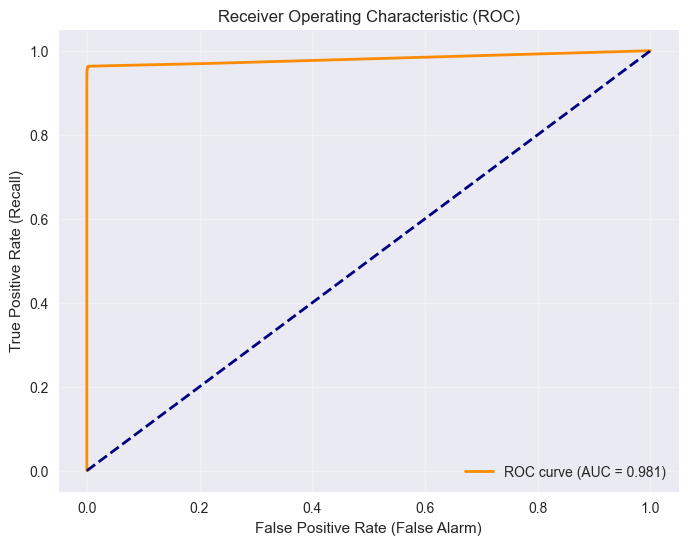

In [6]:
# 获取预测概率 (属于类别 1 的概率)
y_prob = rf_balanced.predict_proba(X_test)[:, 1]

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 绘图
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## 7. 第三阶段：业务落地 (阈值移动)

**这是工业 AI 的核心技巧**。
默认阈值是 0.5。为了进一步降低漏报（提高 Recall），我们可以手动**降低阈值**（如 0.3）。这会牺牲一点精确度，但能挽救更多可能损坏的机器。

In [ ]:
thresholds_to_test = [0.3, 0.5, 0.7]

print("--- 阈值调优分析 (Threshold Tuning) ---")
print(f"{'Threshold':<10} | {'Recall (查全率)':<15} | {'Precision (查准率)':<15}")
print("-"*50)

for t in thresholds_to_test:
    # 如果概率 > t，就认为是故障
    y_pred_t = (y_prob >= t).astype(int)
    
    report = classification_report(y_test, y_pred_t, output_dict=True)
    res = report['1'] 
    
    print(f"{t:<10} | {res['recall']:.4f}          | {res['precision']:.4f}")

print("\n 决策建议：如果这是一台关键设备，建议使用 Threshold=0.3，优先保证 Recall。")

--- 阈值调优分析 (Threshold Tuning) ---
Threshold  | Recall (查全率)    | Precision (查准率)
--------------------------------------------------
0.3        | 0.9615          | 0.9643
0.5        | 0.9528          | 0.9918
0.7        | 0.9178          | 1.0000

💡 决策建议：如果这是一台关键设备，建议使用 Threshold=0.3，优先保证 Recall。


## 8. 特征重要性与抗噪验证

最后验证模型是否聪明地忽略了我们注入的 5 个 `Noise_Sensor`。

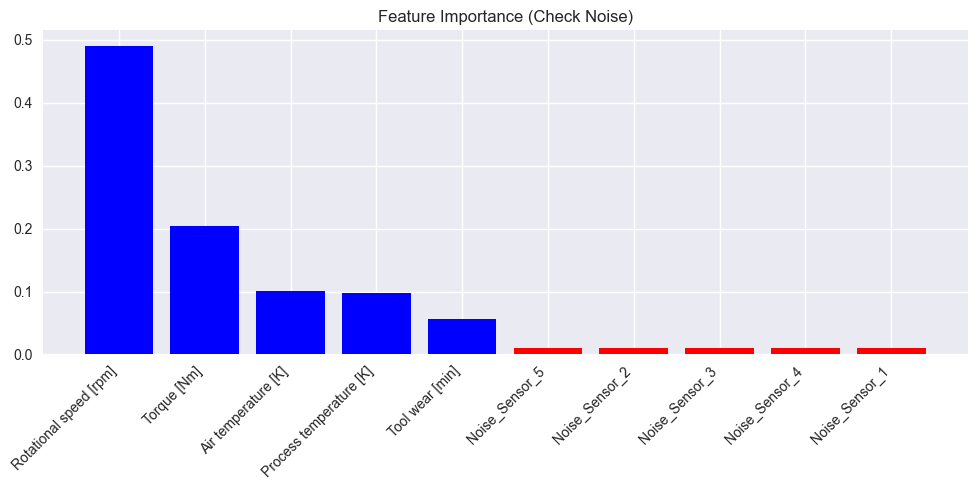

In [8]:
importances = rf_balanced.feature_importances_
indices = np.argsort(importances)[::-1]
names = [X.columns[i] for i in indices]

plt.figure(figsize=(10, 5))
plt.title("Feature Importance (Check Noise)")
colors = ['red' if 'Noise' in name else 'blue' for name in names]
plt.bar(range(X.shape[1]), importances[indices], color=colors)
plt.xticks(range(X.shape[1]), names, rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. 总结与思考

###  关键结论
1.  **不平衡是常态**：在工业故障预测中，永远不要只看准确率。**Recall** 才是生命线。
2.  **加权很有效**：`class_weight='balanced'` 是解决不平衡最简单有效的方法。
3.  **抗噪能力强**：随机森林自动过滤了 5 个噪声特征，展示了其在复杂环境下的鲁棒性。

###  思考题
1.  **阈值选择**：如果这台机器坏了只需要 10块钱维修费，但停机检查一次要花 1000块钱（误报代价 > 漏报代价），你应该把阈值设高还是设低？
2.  **模型迭代**：如果未来工厂加装了一个新的“振动传感器”，我们该如何利用这个新特征？是重新训练模型，还是直接把新特征加进去？

---
**解答**：
1.  **设高 (如 0.8)**。因为误报太贵了，我们希望只有在“非常确定”机器坏了的时候才去检查。
2.  **重新训练**。树模型结构是固定的，必须将新特征加入数据集后，重新构建决策树。